In [1]:
%pip install -r HurrReqs.txt

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu128
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import glob
import os
from shapely.geometry import Point
import re
import pyarrow
import urllib.request
import zipfile
from pygris import counties as get_counties


In [3]:
States = ['FL', 'TX', 'LA', 'MS', 'AL', 'GA', 'SC', 'NC',
    'VA', 'MD', 'DE', 'NJ', 'NY', 'CT', 'RI', 'MA',
    'ME', 'NH', 'PR', 'VI']

print("loading NFIP data...")
nfip_df = pd.read_csv(r'fimaclaims.csv', 
                      dtype={
                           'state':               'str',
                            'dateOfLoss':          'str',
                            'floodEvent':          'str',
                            'causeOfDamage':       'str',
                            'ratedFloodZone':      'str',
                            'countyCode':          'str',
                            'censusTract':         'str',
                            'censusBlockGroupFips':'str',
                            'occupancyType':       'str',
                            'floodZoneCurrent':    'str',
                      },
                    low_memory=False                    
)
print(f'rows: {nfip_df.shape[0]}, columns: {nfip_df.shape[1]}')



loading NFIP data...
rows: 2719462, columns: 73


In [4]:
nfip_df = nfip_df[nfip_df['state'] != 'UN'].copy()
print(f"dropped unknown states, {len(nfip_df)} rows remaining")


nfip_df = nfip_df[nfip_df['state'].isin(States)].copy()
print(f"filtered to coastal states, {len(nfip_df)} rows remaining")

nfip_df = nfip_df.dropna(subset=['latitude', 'longitude'])
print(f'dropped rows with missing latitude or longitude, {len(nfip_df)} rows remaining')

nfip_df['dateOfLoss'] = pd.to_datetime(nfip_df['dateOfLoss'], format='mixed',dayfirst=False)
print(f"\ndateOfLoss range: {nfip_df['dateOfLoss'].min()} -> {nfip_df['dateOfLoss'].max()}")

nfip_df = nfip_df[nfip_df['dateOfLoss'].dt.year >= 1996].copy()
print(f"filtered to 1996 and later, {len(nfip_df)} rows remaining")

hurricane_keywords = ['hurricane', 'tropical storm', 'tropical depression']
pattern = '|'.join(hurricane_keywords)

nfip_df = nfip_df[nfip_df['floodEvent'].str.contains(pattern, case=False, na=False)].copy()
print(f"filtered to hurricane-related events, {len(nfip_df)} rows remaining")

nfip_df = nfip_df[
    nfip_df['buildingDamageAmount'].notna() & (nfip_df['buildingDamageAmount'] > 0)].copy()

print(f"After damage over 0: {len(nfip_df)} rows remaining")

print("\nSample of cleaned NFIP data:")
nfip_df.head(10)

dropped unknown states, 2703021 rows remaining
filtered to coastal states, 2189397 rows remaining
dropped rows with missing latitude or longitude, 2168645 rows remaining

dateOfLoss range: 1978-01-01 00:00:00+00:00 -> 2026-01-11 00:00:00+00:00
filtered to 1996 and later, 1613775 rows remaining
filtered to hurricane-related events, 1135153 rows remaining
After damage over 0: 910075 rows remaining

Sample of cleaned NFIP data:


,agricultureStructureIndicator,asOfDate,basementEnclosureCrawlspaceType,policyCount,crsClassificationCode,dateOfLoss,elevatedBuildingIndicator,elevationCertificateIndicator,elevationDifference,baseFloodElevation,...,rentalPropertyIndicator,state,reportedCity,reportedZipCode,countyCode,censusTract,censusBlockGroupFips,latitude,longitude,id
0,0,2026-01-12T00:00:00.000Z,2.0,1,NaN,2008-09-12 00:00:00+00:00,1,NaN,NaN,NaN,...,0,TX,Currently Unavailable,77650,48167,48167723900,481677239003,29.4,-94.8,4ae4e90e-d6e5-44c3-8b77-09aea5408e13
1,0,2026-01-12T00:00:00.000Z,NaN,1,NaN,2017-08-27 00:00:00+00:00,0,1,NaN,NaN,...,1,TX,Currently Unavailable,77478,48157,48157671601,481576716014,29.6,-95.6,1d64a17f-e908-4016-9936-c6ff3b115867
3,0,2026-01-12T00:00:00.000Z,NaN,1,NaN,2008-09-13 00:00:00+00:00,0,NaN,NaN,NaN,...,0,TX,Currently Unavailable,77037,48201,48201222401,482012224012,29.9,-95.4,75dcdbbf-e3f4-4ea7-a8e5-42fcdc96aeb7
6,0,2026-01-12T00:00:00.000Z,NaN,1,7.0,2012-10-30 00:00:00+00:00,0,NaN,NaN,NaN,...,0,NJ,Currently Unavailable,07734,34025,34025801700,340258017003,40.4,-74.1,33e7e663-c06d-4aa0-9c32-faec151e64cf
7,0,2026-01-12T00:00:00.000Z,NaN,1,NaN,2008-09-13 00:00:00+00:00,1,NaN,6.0,12.0,...,0,TX,Currently Unavailable,77568,48167,48167723800,481677238001,29.3,-94.9,eac519b6-193a-4ed0-b59f-19d2655d12f1
19,0,2026-01-12T00:00:00.000Z,2.0,1,NaN,2011-08-27 00:00:00+00:00,0,1,NaN,NaN,...,0,NJ,Currently Unavailable,08846,34023,34023000200,340230002004,40.6,-74.5,06c6d85d-ea61-487e-ae57-4e8b753318fe
33,0,2026-01-12T00:00:00.000Z,NaN,1,NaN,2016-09-02 00:00:00+00:00,0,NaN,NaN,NaN,...,0,FL,Currently Unavailable,34448,12017,12017451700,120174517002,28.8,-82.6,d77978d7-eaf0-4077-9ebf-52e1949c5950
34,0,2026-01-12T00:00:00.000Z,NaN,1,NaN,2005-08-29 00:00:00+00:00,0,NaN,NaN,NaN,...,0,LA,Currently Unavailable,70122,22071,22071013800,220710138003,30.0,-90.1,a35f4f15-2cf4-4a27-9df1-85d384c9d7d4
36,0,2026-01-12T00:00:00.000Z,0.0,1,NaN,2017-08-26 00:00:00+00:00,0,NaN,NaN,NaN,...,0,TX,Currently Unavailable,77089,48201,48201350300,482013503001,29.6,-95.2,1056485a-03d4-4967-bc99-f42692748a9a
37,0,2026-01-12T00:00:00.000Z,NaN,1,NaN,2011-08-28 00:00:00+00:00,1,NaN,2.0,14.0,...,0,NY,Currently Unavailable,11978,36103,36103190504,361031905041,40.8,-72.7,fff86222-b276-4973-97ff-79088fdc0b3a


In [5]:
flies = sorted(glob.glob('StormEvents_details-ftp_v1.0_d*.csv'))
print(f"loading storm events data from {len(flies)} files...")
storm_df = pd.concat([pd.read_csv(f, low_memory=False) for f in flies],
                      ignore_index=True
                      )
print(f'rows: {storm_df.shape[0]}, columns: {storm_df.shape[1]}')

loading storm events data from 30 files...
rows: 1780611, columns: 51


In [6]:
Hurricane_Event_Types = [
    'Hurricane',
    'Hurricane (Typhoon)',
    'Tropical Storm',
    'Tropical Depression',
    'Storm Surge/Tide',
]

hurricane_episodes = storm_df[storm_df['EVENT_TYPE'].isin(Hurricane_Event_Types)]['EPISODE_ID'].dropna().unique()
print(f"filtered to hurricane-related events, {len(storm_df)} rows remaining")

storm_df = storm_df[storm_df['EPISODE_ID'].isin(hurricane_episodes)].copy()
print(storm_df['EVENT_TYPE'].value_counts().head(10))

filtered to hurricane-related events, 1780611 rows remaining
EVENT_TYPE
Tropical Storm         7146
Hurricane (Typhoon)    2149
Flash Flood            1869
Storm Surge/Tide       1655
Tornado                 590
Tropical Depression     552
Flood                   503
Heavy Rain              278
High Wind               204
Thunderstorm Wind       142
Name: count, dtype: int64


In [7]:
storm_df = storm_df[storm_df['CZ_TYPE'] == 'C'].copy()
print(f"filtered after CZ_TYPE == C, {len(storm_df):,} rows remaining")
def parse_dmg(val):
    if pd.isna(val) or str(val).strip().upper() == '':
        return 0.
    val = str(val).strip().upper()
    multiplier = {'K': 1000, 'M': 1_000_000, 'B': 1_000_000_000}
    if val[-1].upper() in multiplier:
            return float(val[:-1]) * multiplier[val[-1]]
    try:
        return float(val)
    except:
        return 0.0
        
storm_df['DAMAGE_PROPERTY_CLEANED'] = storm_df['DAMAGE_PROPERTY'].apply(parse_dmg)

storm_df['FULL_FIPS'] = (
    storm_df['STATE_FIPS'].astype(float).astype(int).astype(str).str.zfill(2) +
    storm_df['CZ_FIPS'].astype(float).astype(int).astype(str).str.zfill(3)
)

storm_df['BEGIN_DATE_TIME'] = pd.to_datetime(
    storm_df['BEGIN_DATE_TIME'], format='mixed', dayfirst=False)
storm_df['END_DATE_TIME'] = pd.to_datetime(
    storm_df['END_DATE_TIME'], format='mixed', dayfirst=False)

storm_df = storm_df[storm_df['STATE'].isin([
    'FLORIDA', 'TEXAS', 'LOUISIANA', 'MISSISSIPPI', 'ALABAMA',
    'GEORGIA', 'SOUTH CAROLINA', 'NORTH CAROLINA', 'VIRGINIA',
    'MARYLAND', 'DELAWARE', 'NEW JERSEY', 'NEW YORK', 'CONNECTICUT',
    'RHODE ISLAND', 'MASSACHUSETTS', 'MAINE', 'NEW HAMPSHIRE',
    'PUERTO RICO', 'VIRGIN ISLANDS'
])].copy()

print(f"filtered to coastal states, {len(storm_df)} rows remaining")
print("\nSample of cleaned storm events data:")
print(storm_df["EVENT_TYPE"].value_counts())
print("\n storm event cleaning complete.")

filtered after CZ_TYPE == C, 3,645 rows remaining
filtered to coastal states, 3215 rows remaining

Sample of cleaned storm events data:
EVENT_TYPE
Flash Flood          1694
Tornado               571
Flood                 435
Heavy Rain            212
Thunderstorm Wind     119
Storm Surge/Tide      111
Funnel Cloud           27
Debris Flow            23
Hail                   15
Lightning               5
Tropical Storm          2
Waterspout              1
Name: count, dtype: int64

 storm event cleaning complete.


In [8]:
print(storm_df[['EPISODE_ID', 'EVENT_TYPE', 'BEGIN_DATE_TIME', 'FULL_FIPS', 'DAMAGE_PROPERTY_CLEANED']].head(10))
print(f"\nNull FULL_FIPS: {storm_df['FULL_FIPS'].isna().sum()}")
print(f"Null BEGIN_DATE_TIME: {storm_df['BEGIN_DATE_TIME'].isna().sum()}")
print(f"Date range: {storm_df['BEGIN_DATE_TIME'].min()} → {storm_df['BEGIN_DATE_TIME'].max()}")


       EPISODE_ID        EVENT_TYPE     BEGIN_DATE_TIME FULL_FIPS  \
34625   2048422.0  Storm Surge/Tide 1996-09-02 08:00:00     12099   
38891   2056270.0  Storm Surge/Tide 1996-10-20 11:00:00     33015   
39204   2056268.0  Storm Surge/Tide 1996-10-20 11:00:00     23031   
39735   1029280.0  Storm Surge/Tide 1996-10-08 04:00:00     37019   
40127   1023962.0  Storm Surge/Tide 1996-09-06 10:00:00     24003   
40128   2049814.0  Storm Surge/Tide 1996-09-06 10:00:00     24005   
41011   2049793.0  Storm Surge/Tide 1996-09-06 09:00:00     51013   
41012   2049794.0  Storm Surge/Tide 1996-09-06 09:00:00     51059   
41013   2049795.0  Storm Surge/Tide 1996-09-06 09:00:00     51099   
41014   2049796.0  Storm Surge/Tide 1996-09-06 09:00:00     51153   

       DAMAGE_PROPERTY_CLEANED  
34625                      0.0  
38891                 150000.0  
39204                 350000.0  
39735                      0.0  
40127                1400000.0  
40128                 250000.0  
41011    

In [9]:
print(storm_df['FULL_FIPS'].head(5))
print(storm_df['FULL_FIPS'].dtype)

print(storm_df['STATE'].unique())

34625    12099
38891    33015
39204    23031
39735    37019
40127    24003
Name: FULL_FIPS, dtype: str
str
<ArrowStringArray>
[       'FLORIDA',  'NEW HAMPSHIRE',          'MAINE', 'NORTH CAROLINA',
       'MARYLAND',       'VIRGINIA',      'LOUISIANA',    'MISSISSIPPI',
 'SOUTH CAROLINA',     'NEW JERSEY',       'DELAWARE',          'TEXAS',
  'MASSACHUSETTS',   'RHODE ISLAND',        'GEORGIA', 'VIRGIN ISLANDS',
        'ALABAMA',    'PUERTO RICO',    'CONNECTICUT',       'NEW YORK']
Length: 20, dtype: str


METRICS BY YEAR AND HURRICANE

In [10]:
print(f"NFIP year range: {nfip_df['yearOfLoss'].min()} → {nfip_df['yearOfLoss'].max()}")
print(nfip_df['yearOfLoss'].value_counts().sort_index().head(15))

NFIP year range: 1996 → 2024
yearOfLoss
1996     19764
1997       986
1998     18856
1999     37725
2000       314
2001     30346
2002     11481
2003     22100
2004     30074
2005    178273
2006      3393
2007       841
2008     51310
2011     48052
2012    150624
Name: count, dtype: int64


In [11]:
print(nfip_df['floodEvent'].value_counts().head(20))

floodEvent
Hurricane Katrina         154276
Hurricane Sandy           135455
Hurricane Harvey           77114
Hurricane Irene            59771
Hurricane Helene           50934
Hurricane Ike              42878
Hurricane Ian              38035
Tropical Storm Allison     30284
Hurricane Irma             24110
Hurricane Isabel           20879
Hurricane Ida              20750
Hurricane Floyd            20475
Hurricane Matthew          18443
Hurricane Milton           16447
Hurricane Ivan             16059
Hurricane Florence         15128
Hurricane Isaac            13162
Hurricane Fran             10420
Hurricane Wilma             9616
Hurricane Georges           9586
Name: count, dtype: int64


HURDAT PARSER

In [12]:
def parse_hurdat2(filepath):
    storms = []
    current_storm = None
    current_name  = None
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('<') or line == '':
                continue
            if re.match(r'^[A-Z]{2}\d{6}', line):
                parts = [p.strip() for p in line.split(',')]
                current_storm = parts[0]
                current_name  = parts[1].strip()
                continue
            parts = [p.strip() for p in line.split(',')]
            if len(parts) < 8:
                continue
            try:
                storms.append({
                    'storm_id':                     current_storm,
                    'storm_name':                   current_name,
                    'date':                         parts[0].strip(),
                    'time':                         parts[1].strip(),
                    'record_identifier':            parts[2].strip(),
                    'status_of_system':             parts[3].strip(),
                    'latitude': -float(parts[4].replace('N','').replace('S','')) if 'S' in parts[4] else float(parts[4].replace('N','').replace('S','')),
                    'longitude': -float(parts[5].replace('W','').replace('E','')) if 'W' in parts[5] else float(parts[5].replace('E','').replace('W','')),
                    'maximum_sustained_wind_knots': int(parts[6]),
                    'central_pressure_mb':          int(parts[7]),
                    '34_kt_ne_nm': int(parts[8])  if len(parts) > 8  else None,
                    '34_kt_se_nm': int(parts[9])  if len(parts) > 9  else None,
                    '34_kt_sw_nm': int(parts[10]) if len(parts) > 10 else None,
                    '34_kt_nw_nm': int(parts[11]) if len(parts) > 11 else None,
                    '50_kt_ne_nm': int(parts[12]) if len(parts) > 12 else None,
                    '50_kt_se_nm': int(parts[13]) if len(parts) > 13 else None,
                    '50_kt_sw_nm': int(parts[14]) if len(parts) > 14 else None,
                    '50_kt_nw_nm': int(parts[15]) if len(parts) > 15 else None,
                    '64_kt_ne_nm': int(parts[16]) if len(parts) > 16 else None,
                    '64_kt_se_nm': int(parts[17]) if len(parts) > 17 else None,
                    '64_kt_sw_nm': int(parts[18]) if len(parts) > 18 else None,
                    '64_kt_nw_nm': int(parts[19]) if len(parts) > 19 else None,
                    'radius_of_max_wind_nm': int(parts[20]) if len(parts) > 20 else None,
                })
            except (ValueError, IndexError):
                continue
    return pd.DataFrame(storms)
hurdat2_df = parse_hurdat2('hurdat2_2025.csv')
print(f"Raw HURDAT2 rows: {len(hurdat2_df):,}")

# Replace -999 with NaN
wind_cols = [c for c in hurdat2_df.columns if '_kt_' in c or c == 'radius_of_max_wind_nm']
hurdat2_df[wind_cols] = hurdat2_df[wind_cols].replace(-999, np.nan)

# Parse datetime
hurdat2_df['datetime'] = pd.to_datetime(
    hurdat2_df['date'].astype(str) +
    hurdat2_df['time'].astype(str).str.zfill(4),
    format='%Y%m%d%H%M'
)

# Filter to HU, TS, TD
hurdat2_df = hurdat2_df[
    hurdat2_df['status_of_system'].isin(['HU', 'TS', 'TD'])
].copy()

# Clean names
hurdat2_df['storm_name'] = hurdat2_df['storm_name'].str.strip().str.upper()

# Filter to 1996 onward
hurdat2_df = hurdat2_df[hurdat2_df['datetime'].dt.year >= 1996].copy()

print(f"Filtered rows:  {len(hurdat2_df):,}")
print(f"Unique storms:  {hurdat2_df['storm_name'].nunique()}")
print(f"Year range:     {hurdat2_df['datetime'].dt.year.min()} → {hurdat2_df['datetime'].dt.year.max()}")
print(f"Status values:  {hurdat2_df['status_of_system'].unique()}")
print(f"\nSample names:   {hurdat2_df['storm_name'].unique()[:10]}")
print("\nHURDAT2 loading complete ✅")

Raw HURDAT2 rows: 55,605
Filtered rows:  11,222
Unique storms:  185
Year range:     1996 → 2025
Status values:  <ArrowStringArray>
['TD', 'TS', 'HU']
Length: 3, dtype: str

Sample names:   <ArrowStringArray>
[   'ARTHUR',    'BERTHA',     'CESAR',     'DOLLY',   'EDOUARD',      'FRAN',
    'GUSTAV',  'HORTENSE',   'ISIDORE', 'JOSEPHINE']
Length: 10, dtype: str

HURDAT2 loading complete ✅


In [13]:
nfip_df['STORM_NAME_CLEAN'] = (
    nfip_df['floodEvent']
    .str.upper()
    .str.replace('HURRICANE ', '', regex=False)
    .str.replace('TROPICAL STORM ', '', regex=False)
    .str.replace('TROPICAL DEPRESSION ', '', regex=False)
    .str.replace(r'\s*\(.*\)\s*', '', regex=True)
    .str.strip()            
    )

nfip_storms = set(nfip_df['STORM_NAME_CLEAN'].dropna().unique())
hurdat2_storms = set(hurdat2_df['storm_name'].unique())

matched = nfip_storms.intersection(hurdat2_storms)
unmatched_nfip = nfip_storms - hurdat2_storms

print(f"Matched storms: {len(matched)}")
print(f"Unmatched NFIP storms: {len(unmatched_nfip)}")
print(f"\nUnmatched NFIP storm names:\n{sorted(unmatched_nfip)}")

Matched storms: 71
Unmatched NFIP storms: 1

Unmatched NFIP storm names:
['PAUL']


In [14]:
nri_df = pd.read_csv('NRI2025.csv', low_memory=False)
nri_col =[
    'TRACTFIPS',
    'STATEFIPS',
    'COUNTYFIPS',
    'RFLD_AFREQ',
    'CFLD_AFREQ',
    'RFLD_EALB',
    'CFLD_EALB',
    'RFLD_ALRB',
    'CFLD_ALRB',
    'SOVI_SCORE',
    'SOVI_RATNG',
    'RESL_SCORE',
    'RESL_RATNG',
    'RISK_SCORE',
    'RISK_RATNG',
]

existing_columns = [col for col in nri_col if col in nri_df.columns]
missing_columns = [col for col in nri_col if col not in nri_df.columns]

nri_df = nri_df[existing_columns].copy()
if missing_columns:
    print(f"Warning: The following expected columns were not found in the NRI dataset and will be skipped: {missing_columns}")
print(f"NRI columns loaded: {existing_columns}")
print(f"NRI rows: {len(nri_df):,}")

NRI columns loaded: ['TRACTFIPS', 'STATEFIPS', 'COUNTYFIPS', 'CFLD_AFREQ', 'CFLD_EALB', 'CFLD_ALRB', 'SOVI_SCORE', 'SOVI_RATNG', 'RESL_SCORE', 'RESL_RATNG', 'RISK_SCORE', 'RISK_RATNG']
NRI rows: 85,154


In [15]:
counties_gdf = get_counties(year=2023, cb=False)
#converts to lat/lon
counties_gdf = counties_gdf[['GEOID', 'geometry']].to_crs(epsg=4326)
unique_coords = nfip_df[['latitude', 'longitude']].drop_duplicates().dropna().copy()

print(len(unique_coords), "unique lat/lon pairs in NFIP data")

geom =[
    Point(lon, lat) 
    for lon, lat in zip(unique_coords['longitude'], unique_coords['latitude'])
]

gdf_points = gpd.GeoDataFrame(unique_coords.reset_index(drop=True), geometry=geom, crs='EPSG:4326')

joined = gpd.sjoin(gdf_points, counties_gdf, how='left', predicate='within')
print(f"{len(joined[joined['GEOID'].notna()])} points matched to counties")
print(f"{len(joined[joined['GEOID'].isna()])} points NOT matched to counties")

if len(joined[joined['GEOID'].isna()]) > 0:
    nearest_counties = gpd.sjoin_nearest(
        gdf_points[joined['GEOID'].isna()],
        counties_gdf,
        how='left',
        max_distance=0.1,
    )
    print(f"Matched {len(nearest_counties[nearest_counties['GEOID'].notna()])} additional points with nearest join")
    
    all_joined = pd.concat([
        joined[joined['GEOID'].notna()],
        nearest_counties[nearest_counties['GEOID'].notna()]
    ], ignore_index=True
)
else:
    all_joined = joined
nfip_df = nfip_df.drop(columns=['fips_code'], errors='ignore')
nfip_df = nfip_df.merge(
    all_joined[['latitude', 'longitude', 'GEOID']].rename(columns={'GEOID': 'fips_code'}),
    on=['latitude', 'longitude'],
    how='left'
)

print(f"NFIP rows after join:  {len(nfip_df):,}")
print(f"Unique lat/lon after:  {nfip_df[['latitude', 'longitude']].drop_duplicates().shape[0]:,}")
print(f"could not assign fips_code for {nfip_df['fips_code'].isna().sum():,} rows")


5555 unique lat/lon pairs in NFIP data
5539 points matched to counties
16 points NOT matched to counties
Matched 14 additional points with nearest join
NFIP rows after join:  910,075
Unique lat/lon after:  5,555
could not assign fips_code for 2 rows


c:\Users\maxle\UCInsure\.venv\Lib\site-packages\geopandas\array.py:411: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [16]:
CPI_TO_2024 = {
    1996: 1.95, 1997: 1.91, 1998: 1.88, 1999: 1.84, 2000: 1.78,
    2001: 1.73, 2002: 1.70, 2003: 1.66, 2004: 1.61, 2005: 1.56,
    2006: 1.51, 2007: 1.46, 2008: 1.40, 2009: 1.43, 2010: 1.40,
    2011: 1.35, 2012: 1.32, 2013: 1.30, 2014: 1.27, 2015: 1.27,
    2016: 1.26, 2017: 1.22, 2018: 1.18, 2019: 1.16, 2020: 1.14,
    2021: 1.07, 2022: 1.00, 2023: 0.97, 2024: 0.95, 2025: 0.92
}

nfip_df['cpi_multiplier'] = nfip_df['yearOfLoss'].map(CPI_TO_2024)

dmg_cols = ['buildingDamageAmount', 'contentsDamageAmount', 'otherDamageAmount']
for col in dmg_cols:
    if col in nfip_df.columns:
        nfip_df[col + '_2024'] = nfip_df[col] * nfip_df['cpi_multiplier']
        
print("Adjusted damage columns for inflation to 2024 dollars.")
print(f"example building damage before adjustment:\n{nfip_df['buildingDamageAmount'].head(5)}")
print(f"example building damage after adjustment:\n{nfip_df['buildingDamageAmount_2024'].head(5)}")


Adjusted damage columns for inflation to 2024 dollars.
example building damage before adjustment:
0    71876.0
1     6000.0
2     5375.0
3    30337.0
4     2930.0
Name: buildingDamageAmount, dtype: float64
example building damage after adjustment:
0    100626.40
1      7320.00
2      7525.00
3     40044.84
4      4102.00
Name: buildingDamageAmount_2024, dtype: float64


In [22]:
def harverstine_vec(lat1, lon1, lat2_arr, lon2_arr):
    r = 6371.0
    lat1_r = np.radians(lat1)
    lon1_r = np.radians(lon1)
    lat2_r = np.radians(lat2_arr)
    lon2_r = np.radians(lon2_arr)
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r
    a = np.sin(dlat/2)**2 +np.cos(lat1_r) * np.cos(lat2_r) * np.sin(dlon /2) ** 2
    return r * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
hurdat2_df['year'] = hurdat2_df['datetime'].dt.year
track_pts = hurdat2_df[['storm_id', 'year', 'latitude', 'longitude']].drop_duplicates(
    subset = ['storm_id', 'latitude', 'longitude']
)

print(f"HURDAT2 track points (deduplicated): {len(track_pts):,}")
print(f"Year range: {track_pts['year'].min()} – {track_pts['year'].max()}")

N_YEARS = track_pts['year'].max() - track_pts['year'].min() + 1
print(f"HURDAT2 span: {N_YEARS} years")


LAT_MIN, LAT_MAX = 5.00, 50.00
LON_MIN, LON_MAX = -105.00, -55.00
GRID_RES = 0.5
SEARCH_RADIUS_KM = 150

lats = np.arange(LAT_MIN, LAT_MAX + GRID_RES, GRID_RES)
lons = np.arange(LON_MIN, LON_MAX + GRID_RES, GRID_RES)
grid_lats, grid_lons = np.meshgrid(lats, lons)
grid_lats = grid_lats.ravel()
grid_lons = grid_lons.ravel()

print(f"Grid cells: {len(grid_lats):,} ({len(lats)} lat × {len(lons)} lon)")

try:
    from tqdm import tqdm
    iterator = tqdm(range(len(grid_lats)), desc="Computing λ grid")
except:
    iterator =  range(len(grid_lats))
    print("tqdm not installed — no progress bar. Run: pip install tqdm")
    
track_lats = track_pts['latitude'].values
track_lons = track_pts['longitude'].values
track_storm_ids = track_pts['storm_id'].values
passage_counts = np.zeros(len(grid_lats), dtype=np.int32)

for i in iterator:
    dist = harverstine_vec(grid_lats[i], grid_lons[i],track_lats, track_lons)
    nearby_mask = dist <= SEARCH_RADIUS_KM
    passage_counts[i] = len(np.unique(track_storm_ids[nearby_mask]))
    
lambda_grid =pd.DataFrame({
    'lat': grid_lats,
    'lon': grid_lons,
    'storm_count': passage_counts,
    'lambda': passage_counts / N_YEARS,
    'low_data_flag': passage_counts == 0,
})

print(f"\nλ grid summary:")
print(f"  Cells with λ > 0:      {(~lambda_grid['low_data_flag']).sum():,}")
print(f"  Cells with λ = 0:      {lambda_grid['low_data_flag'].sum():,}")
print(f"  Max λ (hottest cell):  {lambda_grid['lambda'].max():.4f} storms/year")
print(f"  Mean λ (active cells): {lambda_grid.loc[~lambda_grid['low_data_flag'], 'lambda'].mean():.4f} storms/year")

HURDAT2 track points (deduplicated): 11,189
Year range: 1996 – 2025
HURDAT2 span: 30 years
Grid cells: 9,191 (91 lat × 101 lon)


Computing λ grid: 100%|██████████| 9191/9191 [00:01<00:00, 5379.84it/s]


λ grid summary:
  Cells with λ > 0:      6,334
  Cells with λ = 0:      2,857
  Max λ (hottest cell):  1.2667 storms/year
  Mean λ (active cells): 0.4459 storms/year


In [26]:
lambda_lookup = {
    (round(lat, 6), round(lon, 6)): (lam, flag)
    for lat, lon, lam, flag in zip(
        lambda_grid['lat'],
        lambda_grid['lon'],
        lambda_grid['lambda'],
        lambda_grid['low_data_flag']
    )
}
 
def snap_to_grid(lat, lon, res=0.5):
    return round(round(lat / res) * res, 6), round(round(lon / res) * res, 6)
 
def lookup_lambda(lat, lon, res=0.5):
    if pd.isna(lat) or pd.isna(lon):
        return (0.0, True)
    key = snap_to_grid(lat, lon, res)
    return lambda_lookup.get(key, (0.0, True))

print("Joining λ onto storm_df (NOAA Storm Events)...")
storm_lambda = storm_df.apply(
    lambda row: lookup_lambda(row['BEGIN_LAT'], row['BEGIN_LON']),
    axis=1
)
storm_df[['lambda', 'low_data_flag']] = pd.DataFrame(
    storm_lambda.tolist(), index=storm_df.index
)
 
storm_flagged = storm_df['low_data_flag'].sum()
print(f"  storm_df records:{len(storm_df):,}")
print(f"  Flagged low_data:{storm_flagged:,} ({storm_flagged/len(storm_df)*100:.1f}%)")

print("\nJoining λ onto nfip_df (NFIP Claims)...")   
nfip_lambda = nfip_df.apply(
    lambda row: lookup_lambda(row['latitude'], row['longitude']),
    axis=1   
)
nfip_df[['lambda', 'low_data_flag']] = pd.DataFrame(
    nfip_lambda.tolist(), index=nfip_df.index   
)
 
nfip_flagged = nfip_df['low_data_flag'].sum()  
print(f"  nfip_df records:{len(nfip_df):,}") 
print(f"  Flagged low_data:{nfip_flagged:,} ({nfip_flagged/len(nfip_df)*100:.1f}%)")
 
print("\nλ join complete. Columns added: 'lambda', 'low_data_flag'")

Joining λ onto storm_df (NOAA Storm Events)...
  storm_df records:3,215
  Flagged low_data:323 (10.0%)

Joining λ onto nfip_df (NFIP Claims)...
  nfip_df records:910,075
  Flagged low_data:433 (0.0%)

λ join complete. Columns added: 'lambda', 'low_data_flag'


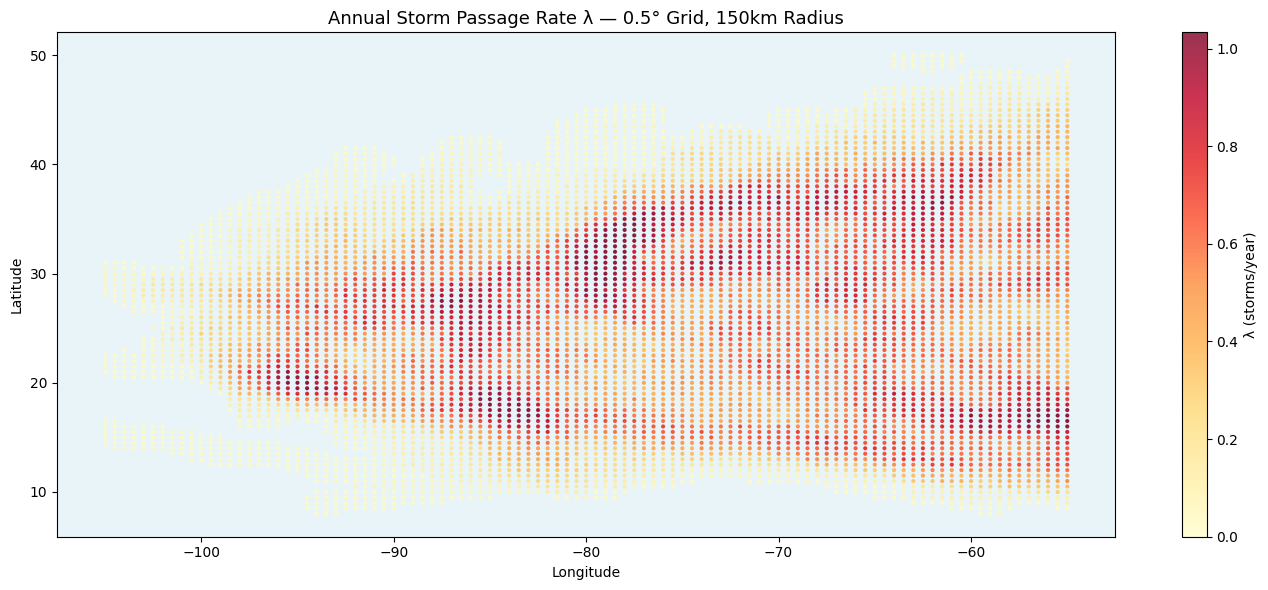

Saved → lambda_grid_heatmap.png

λ distribution in storm_df (active cells only):
count    2892.0000
mean        0.5718
std         0.2529
min         0.0333
25%         0.4000
50%         0.5667
75%         0.7333
max         1.1333
Name: lambda, dtype: float64

λ distribution in nfip_df (active cells only):
count    909642.0000
mean          0.5533
std           0.2154
min           0.0333
25%           0.4000
50%           0.5333
75%           0.7333
max           1.1333
Name: lambda, dtype: float64

=== LOW DATA FLAG SUMMARY ===
storm_df:  10.05% of records flagged
nfip_df:   0.05% of records flagged
Flagged records will return λ=0 at inference.
Frontend note: 'Limited historical storm data for this area — may be lower risk.'


In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
active = lambda_grid[~lambda_grid['low_data_flag']]
scatter = ax.scatter(
    active['lon'], active['lat'],
    c=active['lambda'], cmap='YlOrRd',
    s=4, alpha=0.8,
    vmin=0, vmax=active['lambda'].quantile(0.99)
)
plt.colorbar(scatter, ax=ax, label='λ (storms/year)')
ax.set_title('Annual Storm Passage Rate λ — 0.5° Grid, 150km Radius', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_facecolor('#e8f4f8')
plt.tight_layout()
plt.savefig('lambda_grid_heatmap.png', dpi=150)
plt.show()
print("Saved → lambda_grid_heatmap.png")

print("\nλ distribution in storm_df (active cells only):")
print(storm_df.loc[~storm_df['low_data_flag'], 'lambda'].describe().round(4))
 
print("\nλ distribution in nfip_df (active cells only):")
print(nfip_df.loc[~nfip_df['low_data_flag'], 'lambda'].describe().round(4))
 
# --- Flag summary ------------------------------------------------------------
print("\n=== LOW DATA FLAG SUMMARY ===")
print(f"storm_df:  {storm_df['low_data_flag'].mean()*100:.2f}% of records flagged")
print(f"nfip_df:   {nfip_df['low_data_flag'].mean()*100:.2f}% of records flagged")
print("Flagged records will return λ=0 at inference.")
print("Frontend note: 'Limited historical storm data for this area — may be lower risk.'")

In [28]:
GEOM_COLS = ['geometry', 'index_right']

nfip_df_save    = nfip_df.drop(columns=[c for c in GEOM_COLS if c in nfip_df.columns])
storm_df_save   = storm_df.drop(columns=[c for c in GEOM_COLS if c in storm_df.columns])
hurdat2_df_save = hurdat2_df.drop(columns=[c for c in GEOM_COLS if c in hurdat2_df.columns])
nri_df_save     = nri_df.drop(columns=[c for c in GEOM_COLS if c in nri_df.columns])

nfip_df.to_parquet('nfip_clean.parquet', index=False)
storm_df.to_parquet('storm_events_clean.parquet', index=False)
hurdat2_df.to_parquet('hurdat2_clean.parquet', index=False)
nri_df.to_parquet('nri_clean.parquet', index=False)
lambda_grid.to_parquet('lambda_grid.parquet', index=False)

print("All cleaned datasets saved as parquet files.")
print(f"cleaned NFIP rows: {len(nfip_df):,}")
print(f"cleaned storm events rows: {len(storm_df):,}")
print(f"cleaned HURDAT2 rows: {len(hurdat2_df):,}")
print(f"cleaned NRI rows: {len(nri_df):,}")
print(f"lambda grid cells:{len(lambda_grid):,}")

All cleaned datasets saved as parquet files.
cleaned NFIP rows: 910,075
cleaned storm events rows: 3,215
cleaned HURDAT2 rows: 11,222
cleaned NRI rows: 85,154
lambda grid cells:9,191
